# Practical 2

## Which images did we disagree on?

In [11]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import SVG, Markdown, display
from ipywidgets import IntSlider, Layout, interact

plt.rcParams.update({"font.size": 22, "figure.dpi": 100})

submissions_dir = Path("submissions-2-quality-control")
practical_dir = Path("..") / "practical-2-quality-control"

labels = {
    "skull_strip_report": "Skull stripping",
    "t1_norm_rpt": "T1w normalization",
    "epi_norm_rpt": "EPI normalization",
    "tsnr_rpt": "tSNR",
    "bold_conf": "Carpet plot",
    "ica_aroma": "ICA-AROMA",
}
colors = {"good": "#2e7d32", "uncertain": "#f9a825", "bad": "#c62828"}

Read all submissions and keep only the subjects from the practical. Images without a rating are dropped.

In [12]:
paths = sorted(submissions_dir.glob("*.json"))
records = list()
for path in paths:
    records.extend(json.loads(path.read_text()))
ratings = pd.DataFrame(records)

subjects = {path.name.removeprefix("sub-") for path in practical_dir.glob("sub-*")}
ratings = ratings[ratings["sub"].isin(subjects) & ratings["rating"].isin(colors)].copy()


def image_path(row: pd.Series) -> str:
    if pd.isna(row["task"]):
        return f"sub-{row['sub']}/figures/sub-{row['sub']}_{row['type']}.svg"
    prefix = f"sub-{row['sub']}_ses-{row['ses']}_task-{row['task']}_run-{row['run']}"
    return f"sub-{row['sub']}/ses-{row['ses']}/figures/{prefix}_{row['type']}.svg"


ratings["image"] = ratings.apply(image_path, axis=1)
ratings["label"] = "sub-" + ratings["sub"] + "  " + ratings["type"].map(labels)

display(Markdown(f"## {len(paths)} submissions · {ratings['image'].nunique()} images · {len(subjects)} subjects"))

## 21 submissions · 90 images · 15 subjects

An image is **controversial** when the ratings are spread out. We score *good* as 0, *uncertain* as ½ and *bad* as 1. The controversy is the standard deviation of these scores, scaled so that 100 % means an even split between *good* and *bad*.

In [13]:
counts = (
    ratings.groupby(["image", "label"])["rating"]
    .value_counts()
    .unstack(fill_value=0)
    .reindex(columns=list(colors), fill_value=0)
    .reset_index("label")
)
scores = ratings["rating"].map({"good": 0.0, "uncertain": 0.5, "bad": 1.0})
counts["controversy"] = 2 * scores.groupby(ratings["image"]).std(ddof=0)

ranking = counts.sort_values(["controversy", "bad"], ascending=False)
ranking = ranking[ranking["controversy"] > 0]

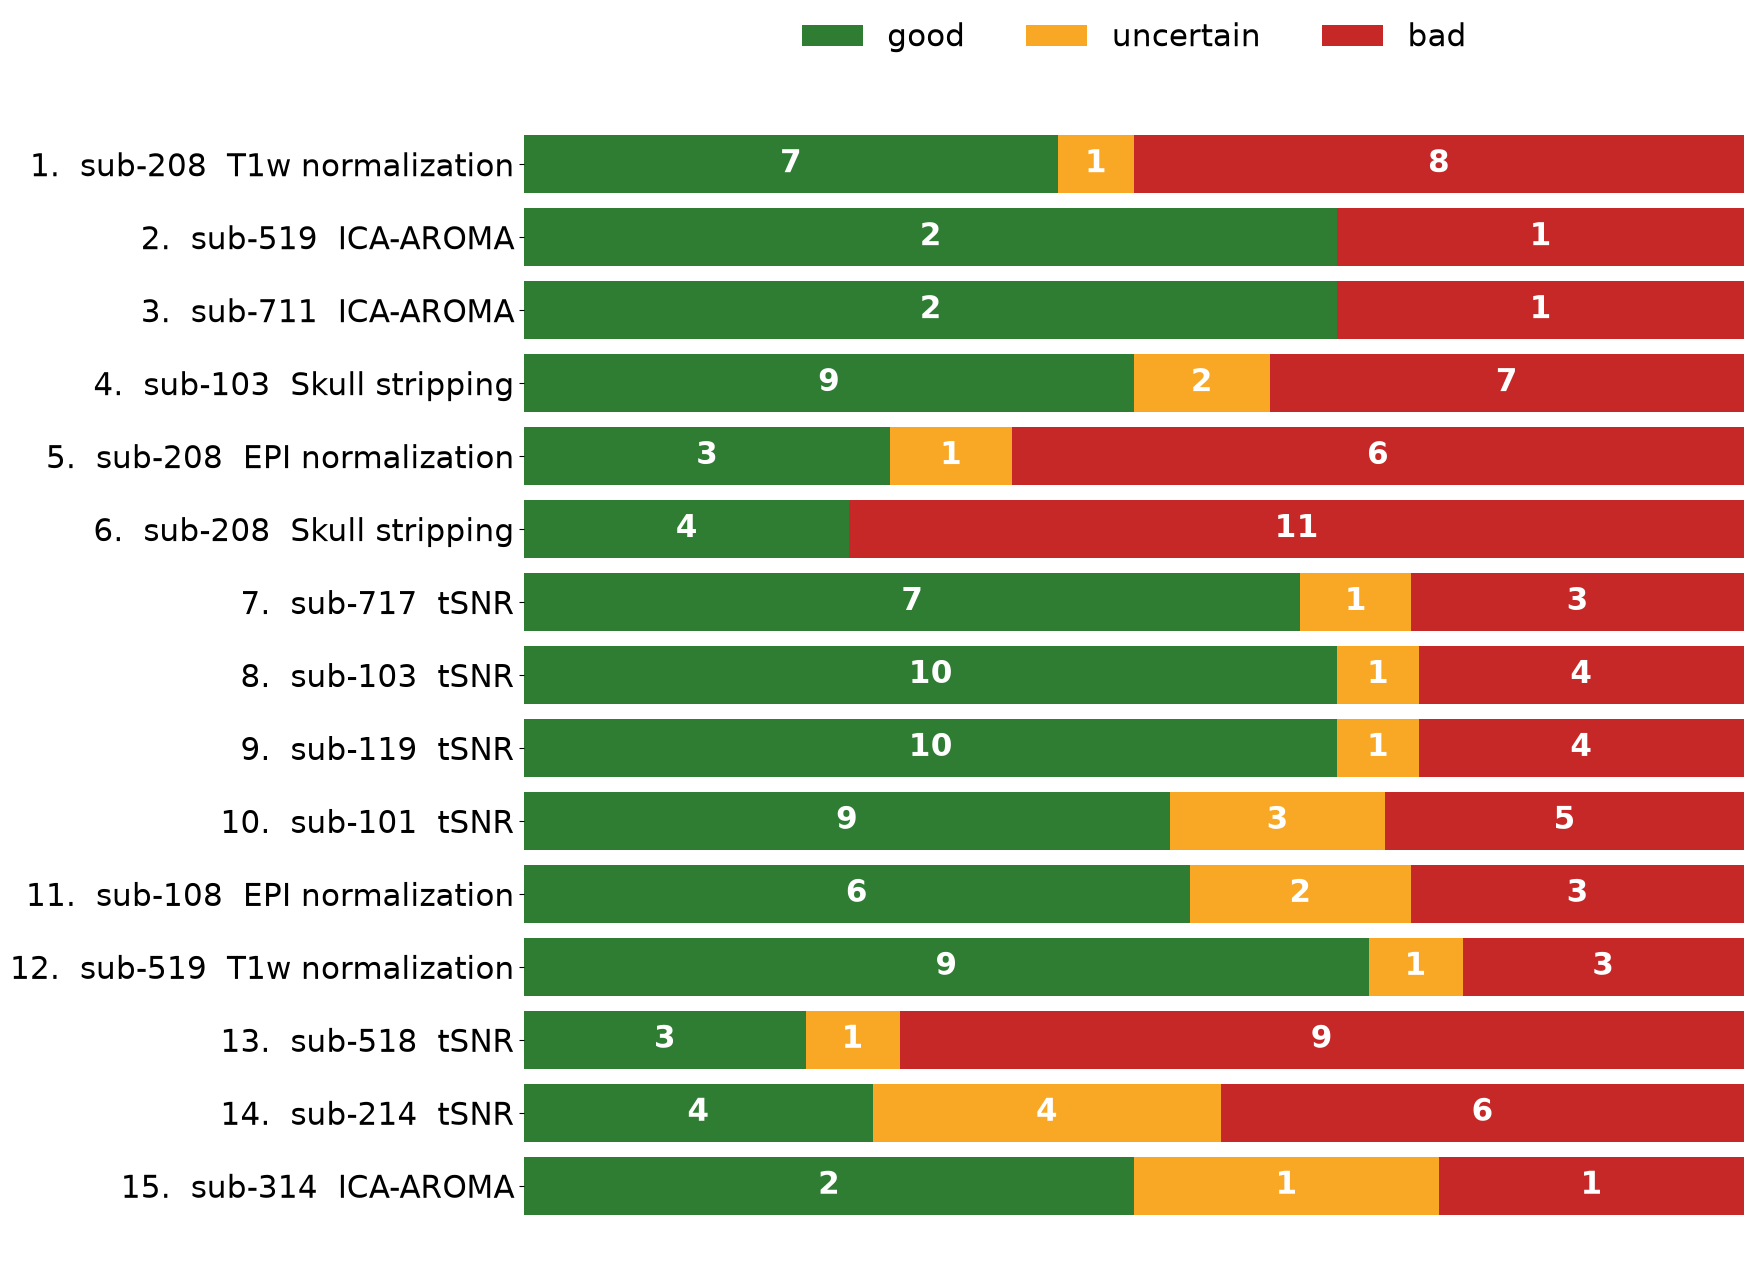

In [14]:
top = ranking.head(15).iloc[::-1]
fractions = top[list(colors)].div(top[list(colors)].sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(18, 0.75 * len(top) + 2))
left = pd.Series(0.0, index=top.index)
for rating, color in colors.items():
    bars = ax.barh(top["label"], fractions[rating], left=left, color=color, label=rating)
    ax.bar_label(bars, labels=[str(n) if n else "" for n in top[rating]], label_type="center", color="white", weight="bold")
    left += fractions[rating]

ax.set_yticks(range(len(top)), [f"{len(top) - i}.  {label}" for i, label in enumerate(top["label"])])
ax.set_xlim(0, 1)
ax.set_xticks([])
ax.spines[:].set_visible(False)
ax.legend(ncols=3, loc="lower center", bbox_to_anchor=(0.5, 1), frameon=False)
fig.tight_layout()

Step through the ranking to look at each image.

In [16]:
def show(rank: int) -> None:
    row = ranking.iloc[rank - 1]
    display(Markdown(f"## {rank}. {row['label']} — {row['good']} good · {row['uncertain']} uncertain · {row['bad']} bad"))
    display(SVG(filename=practical_dir / row.name))


interact(show, rank=IntSlider(value=1, min=1, max=len(ranking), layout=Layout(width="80%")));

interactive(children=(IntSlider(value=1, description='rank', layout=Layout(width='80%'), max=84, min=1), Outpu…